In [1]:
!pip install -q datasets nltk scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print(dataset)

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [5]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training data:", train_df.shape)
print("Validation data:", validation_df.shape)
print("Testing data:", test_df.shape)

Training data: (45615, 2)
Validation data: (2000, 2)
Testing data: (12284, 2)


In [6]:
print(train_df.head())

                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2


In [9]:
label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

In [10]:
train_df["sentiment"] = train_df["label"].map(label_names)
validation_df["sentiment"] = validation_df["label"].map(label_names)
test_df["sentiment"] = test_df["label"].map(label_names)

train_df.head()

,text,label,sentiment
0,"""QT @user In the original draft of the 7th boo...",2,Positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,Neutral
2,Sorry bout the stream last night I crashed out...,1,Neutral
3,Chase Headley's RBI double in the 8th inning o...,1,Neutral
4,@user Alciato: Bee will invest 150 million in ...,2,Positive


In [11]:
print(train_df["sentiment"].value_counts())

sentiment
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


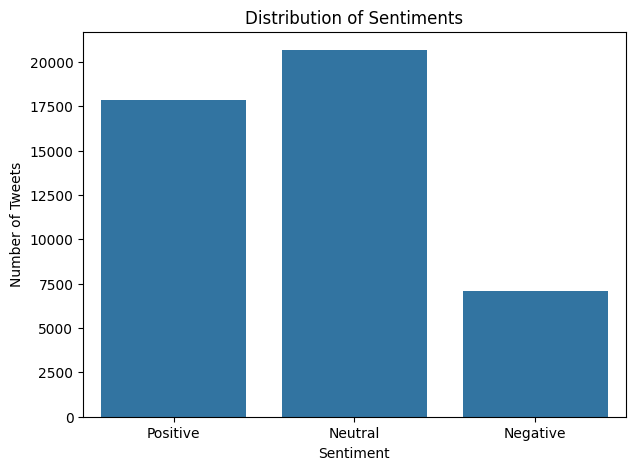

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_df,
    x="sentiment"
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [13]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words
    text = " ".join(words)

    return text

In [14]:
example = train_df["text"].iloc[0]

print("Original:")
print(example)

print("\nCleaned:")
print(clean_text(example))

Original:
"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"

Cleaned:
qt original draft th book remus lupin survived battle hogwarts happybirthdayremuslupin


In [15]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
validation_df["clean_text"] = validation_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [16]:
train_df[["text", "clean_text", "sentiment"]].head(10)

,text,clean_text,sentiment
0,"""QT @user In the original draft of the 7th boo...",qt original draft th book remus lupin survived...,Positive
1,"""Ben Smith / Smith (concussion) remains out of...",ben smith smith concussion remains lineup thur...,Neutral
2,Sorry bout the stream last night I crashed out...,sorry bout stream last night crashed tonight s...,Neutral
3,Chase Headley's RBI double in the 8th inning o...,chase headleys rbi double th inning david pric...,Neutral
4,@user Alciato: Bee will invest 150 million in ...,alciato bee invest million january another sum...,Positive
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,lit mum kerry louboutins wonder many willam ow...,Positive
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",soul train oct halloween special ft tdot fines...,Positive
7,So disappointed in wwe summerslam! I want to s...,disappointed wwe summerslam want see john cena...,Negative
8,"""This is the last Sunday w/o football .....,NF...",last sunday wo football nfl back baby,Positive
9,@user @user CENA & AJ sitting in a tree K-I-S-...,cena aj sitting tree kissing st go ajs job joh...,Neutral


In [17]:
train_df = train_df[train_df["clean_text"].str.strip() != ""]
validation_df = validation_df[
    validation_df["clean_text"].str.strip() != ""
]
test_df = test_df[
    test_df["clean_text"].str.strip() != ""
]

In [18]:
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_validation = validation_df["clean_text"]
y_validation = validation_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

In [19]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_validation_tfidf = tfidf.transform(X_validation)

X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (45615, 10000)
Testing shape: (12282, 10000)


In [20]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [21]:
y_pred = model.predict(X_test_tfidf)

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.5907018400911903
Accuracy Percentage: 59.07018400911903 %


In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.67      0.39      0.50      3972
     Neutral       0.59      0.73      0.66      5935
    Positive       0.51      0.57      0.54      2375

    accuracy                           0.59     12282
   macro avg       0.59      0.56      0.56     12282
weighted avg       0.60      0.59      0.58     12282



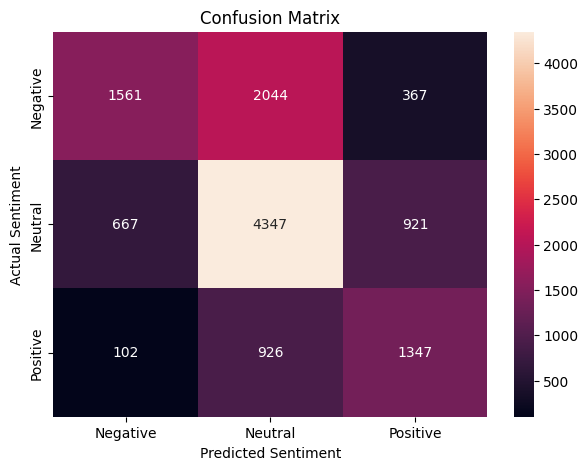

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [25]:
def predict_sentiment(tweet):

    cleaned = clean_text(tweet)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    sentiment = label_names[prediction]

    return sentiment

In [26]:
tweet = "I absolutely love this new phone! It is amazing!"

print("Tweet:", tweet)
print("Predicted Sentiment:", predict_sentiment(tweet))

Tweet: I absolutely love this new phone! It is amazing!
Predicted Sentiment: Positive


In [27]:
tweets = [
    "I love this product! It is amazing!",
    "This is the worst experience ever.",
    "The movie starts at 7 PM today.",
    "I am extremely happy with the service.",
    "The customer support was terrible.",
    "I went to college today."
]

for tweet in tweets:

    sentiment = predict_sentiment(tweet)

    print("Tweet:", tweet)
    print("Sentiment:", sentiment)
    print("-" * 60)

Tweet: I love this product! It is amazing!
Sentiment: Positive
------------------------------------------------------------
Tweet: This is the worst experience ever.
Sentiment: Negative
------------------------------------------------------------
Tweet: The movie starts at 7 PM today.
Sentiment: Neutral
------------------------------------------------------------
Tweet: I am extremely happy with the service.
Sentiment: Positive
------------------------------------------------------------
Tweet: The customer support was terrible.
Sentiment: Negative
------------------------------------------------------------
Tweet: I went to college today.
Sentiment: Neutral
------------------------------------------------------------


In [29]:
while True:

    tweet = input("\nEnter a tweet (or type 'exit' to stop): ")

    if tweet.lower() == "exit":
        print("Sentiment analysis stopped.")
        break

    sentiment = predict_sentiment(tweet)

    print("Predicted Sentiment:", sentiment)


Enter a tweet (or type 'exit' to stop): I had such a wonderful day!
Predicted Sentiment: Positive

Enter a tweet (or type 'exit' to stop): exit
Sentiment analysis stopped.


In [30]:
!pip install -q vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [31]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [32]:
def vader_sentiment(tweet):

    score = analyzer.polarity_scores(tweet)

    compound = score["compound"]

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [33]:
tweets = [
    "I absolutely love this!",
    "This is horrible!",
    "The weather is okay today."
]

for tweet in tweets:

    print("Tweet:", tweet)
    print("VADER:", vader_sentiment(tweet))
    print("ML Model:", predict_sentiment(tweet))
    print("-" * 50)

Tweet: I absolutely love this!
VADER: Positive
ML Model: Positive
--------------------------------------------------
Tweet: This is horrible!
VADER: Negative
ML Model: Negative
--------------------------------------------------
Tweet: The weather is okay today.
VADER: Positive
ML Model: Neutral
--------------------------------------------------
